# Function 8 — Landscape Analysis and Surrogate Diagnosis

**Context:** F8 is the highest-dimensional function (8D, complex ML hyperparameters) with n=50 total observations (40 initial + 10 submitted). The best result is Y=9.875 (W9) at a point with strong dimensional structure: D1/D3/D4 near zero, D5 near 1.0, D7 ≈ 0.33.

**The problem:** Despite clear patterns in the top results, the GP with Matérn 5/2 and low-ξ EI continues to suggest queries far from the known good region. W10's query moved 0.92 units from W9 (D4: 0.015→0.711, D5: 0.965→0.689) and returned 9.166 — a clear regression.

**Hypothesis:** At n=50 in 8D (6.25 points per dimension), the GP cannot learn the correct length-scale structure. ARD length-scales are all > 2.0, making the GP see the function as nearly flat, which causes the acquisition function to explore high-uncertainty corners rather than exploit the confirmed basin.

**Experiments:**
1. Data overview and dimension classification
2. Radial decay analysis
3. GP length-scale diagnosis across kernels
4. Acquisition function pathology — where does EI think the optimum is?
5. Effective dimensionality analysis
6. Model-free dimension importance (rank-based)
7. Local basin characterisation
8. Candidate recommendations

---

In [1]:
import sys, os, json, warnings
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), ''))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr, norm
from scipy.spatial.distance import cdist
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C, RBF, RationalQuadratic
from sklearn.model_selection import LeaveOneOut

print('Libraries loaded.')

Libraries loaded.


In [2]:
X_init = np.load('../initial_data/function_8/initial_inputs.npy')
Y_init = np.load('../initial_data/function_8/initial_outputs.npy').ravel()

with open('../capstone_history.json') as f:
    hist = json.load(f)['8']

X_sub = np.array(hist['X'])
Y_sub = np.array(hist['Y'])

X_all = np.vstack([X_init, X_sub])
Y_all = np.concatenate([Y_init, Y_sub])

labels = (['init'] * len(X_init)) + [f'W{i+1}' for i in range(len(X_sub))]

dim_names = [f'D{i+1}' for i in range(8)]

Y_mean, Y_std = Y_all.mean(), Y_all.std()
Y_z = (Y_all - Y_mean) / Y_std

best_idx = np.argmax(Y_all)
best_x = X_all[best_idx]
top5_idx = np.argsort(Y_all)[-5:]
centroid = X_all[top5_idx].mean(axis=0)

print(f'Total observations: {len(X_all)} (initial={len(X_init)}, submitted={len(X_sub)})')
print(f'Y range: [{Y_all.min():.4f}, {Y_all.max():.4f}], mean={Y_mean:.4f}, std={Y_std:.4f}')
print(f'Best: Y={Y_all[best_idx]:.4f} at [{" ".join(f"{v:.3f}" for v in best_x)}]')
print(f'Data density: {len(X_all)/8:.1f} points per dimension')

Total observations: 50 (initial=40, submitted=10)
Y range: [5.5922, 9.8753], mean=8.0962, std=1.0755
Best: Y=9.8753 at [0.080 0.220 0.003 0.015 0.965 0.506 0.326 0.871]
Data density: 6.2 points per dimension


## 1. Dimension Classification

Classify each dimension by how tightly constrained it is in the top-5 results. Dimensions with small spread in the top-5 are critical; those with large spread are effectively irrelevant to the optimum.

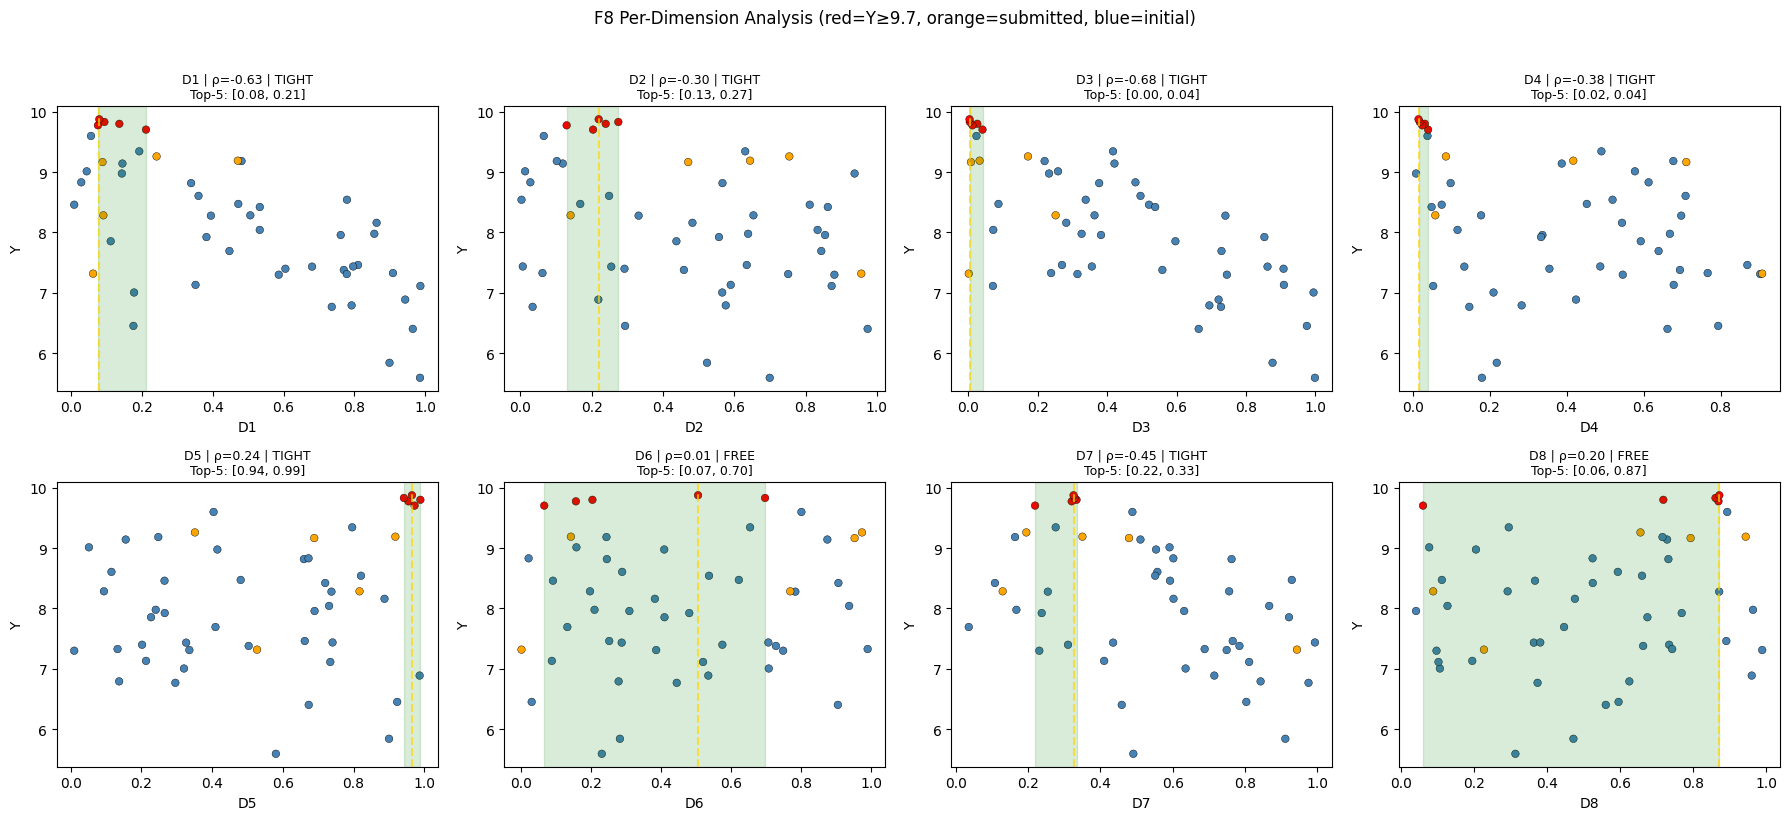

 dim       rho            p   t5_min   t5_max  t5_mean   spread
   1 -0.634574 7.471360e-07 0.076117 0.211707 0.119672 0.135590
   2 -0.303145 3.235622e-02 0.130080 0.274932 0.213714 0.144852
   3 -0.679232 5.870309e-08 0.003011 0.040404 0.016801 0.037393
   4 -0.379112 6.625747e-03 0.015499 0.040332 0.026300 0.024833
   5  0.237935 9.613382e-02 0.942388 0.988952 0.964818 0.046564
   6  0.010036 9.448526e-01 0.066676 0.697247 0.326257 0.630571
   7 -0.453926 9.296770e-04 0.219298 0.333825 0.305557 0.114527
   8  0.200288 1.631343e-01 0.061115 0.871403 0.676189 0.810288


In [3]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

dim_stats = []
for dim, ax in enumerate(axes.ravel()):
    rho, p = spearmanr(X_all[:, dim], Y_all)
    t5_vals = X_all[top5_idx, dim]
    spread = t5_vals.max() - t5_vals.min()
    
    dim_stats.append({'dim': dim+1, 'rho': rho, 'p': p, 
                      't5_min': t5_vals.min(), 't5_max': t5_vals.max(),
                      't5_mean': t5_vals.mean(), 'spread': spread})
    
    colors = []
    for k, l in enumerate(labels):
        if Y_all[k] >= 9.7:  colors.append('red')
        elif l.startswith('W'): colors.append('orange')
        else: colors.append('steelblue')
    
    ax.scatter(X_all[:, dim], Y_all, c=colors, s=30, edgecolors='black', linewidth=0.3)
    ax.axvspan(t5_vals.min(), t5_vals.max(), alpha=0.15, color='green')
    ax.axvline(best_x[dim], color='gold', ls='--', alpha=0.7)
    ax.set_xlabel(f'D{dim+1}')
    ax.set_ylabel('Y')
    
    category = 'TIGHT' if spread < 0.15 else ('FREE' if spread > 0.40 else 'MODERATE')
    ax.set_title(f'D{dim+1} | ρ={rho:.2f} | {category}\nTop-5: [{t5_vals.min():.2f}, {t5_vals.max():.2f}]', fontsize=9)

plt.suptitle('F8 Per-Dimension Analysis (red=Y≥9.7, orange=submitted, blue=initial)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('figures/f8_dimension_classification.png', dpi=150, bbox_inches='tight')
plt.show()

stats_df = pd.DataFrame(dim_stats)
print(stats_df.to_string(index=False))

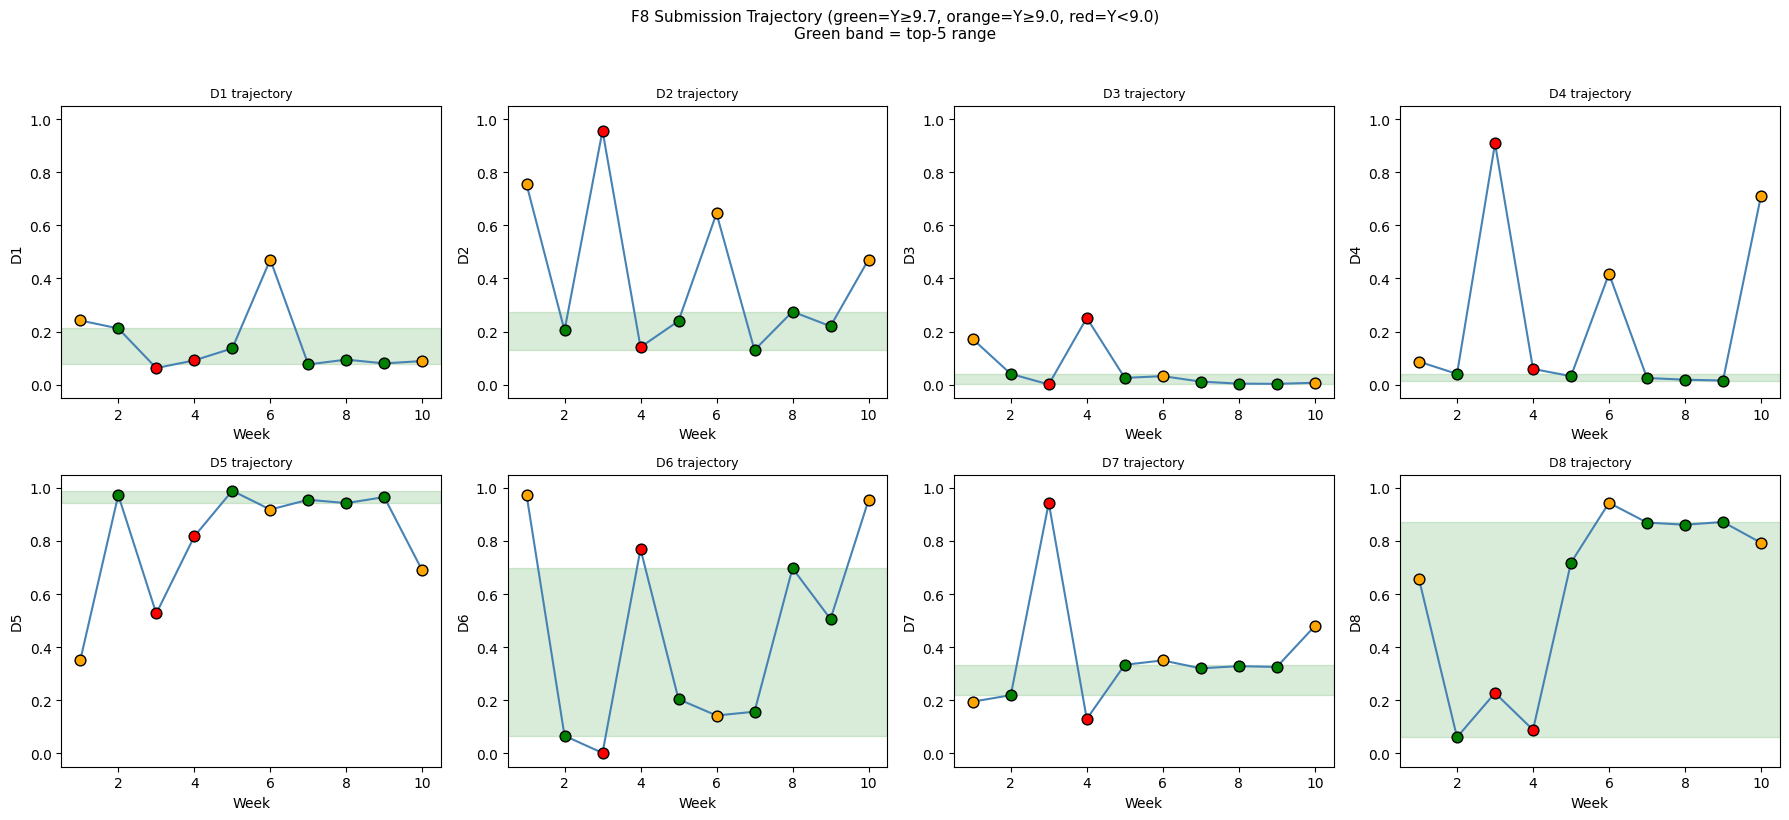

In [4]:
# Submission trajectory: show how each dimension changed across W1-W10
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
weeks = np.arange(1, 11)

for dim, ax in enumerate(axes.ravel()):
    ax.plot(weeks, X_sub[:, dim], 'o-', color='steelblue', ms=6, lw=1.5)
    
    # Colour by outcome
    for w in range(10):
        c = 'green' if Y_sub[w] >= 9.7 else ('orange' if Y_sub[w] >= 9.0 else 'red')
        ax.scatter(w+1, X_sub[w, dim], c=c, s=60, edgecolors='black', zorder=5)
    
    # Top-5 band
    t5_vals = X_all[top5_idx, dim]
    ax.axhspan(t5_vals.min(), t5_vals.max(), alpha=0.15, color='green')
    ax.set_xlabel('Week'); ax.set_ylabel(f'D{dim+1}')
    ax.set_title(f'D{dim+1} trajectory', fontsize=9)
    ax.set_xlim(0.5, 10.5)
    ax.set_ylim(-0.05, 1.05)

plt.suptitle('F8 Submission Trajectory (green=Y≥9.7, orange=Y≥9.0, red=Y<9.0)\nGreen band = top-5 range', fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('figures/f8_submission_trajectory.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Radial Decay Analysis

Spearman(dist_from_best, Y):     ρ=-0.8612, p=1.03e-15
Spearman(dist_from_centroid, Y):  ρ=-0.8962, p=1.46e-18
Spearman(dist_tight_dims, Y):     ρ=-0.8927, p=3.08e-18


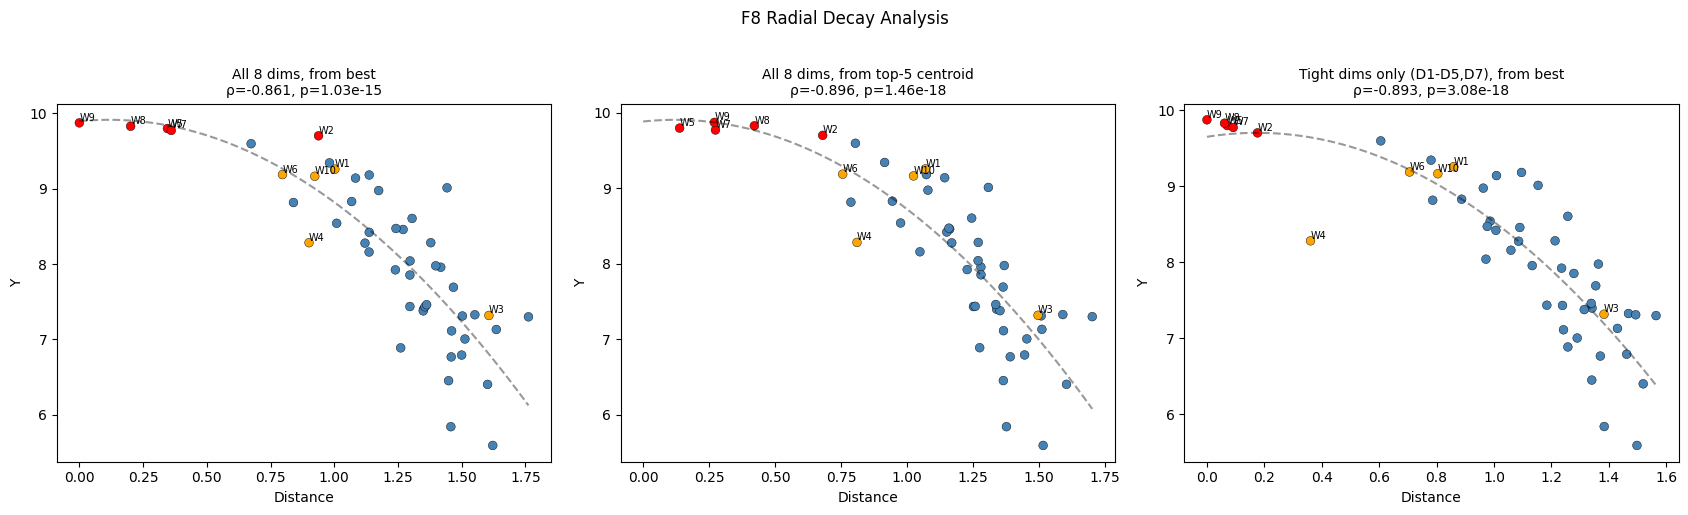

In [5]:
dist_from_best = np.linalg.norm(X_all - best_x, axis=1)
rho_best, p_best = spearmanr(dist_from_best, Y_all)

dist_from_centroid = np.linalg.norm(X_all - centroid, axis=1)
rho_cent, p_cent = spearmanr(dist_from_centroid, Y_all)

print(f'Spearman(dist_from_best, Y):     ρ={rho_best:.4f}, p={p_best:.2e}')
print(f'Spearman(dist_from_centroid, Y):  ρ={rho_cent:.4f}, p={p_cent:.2e}')

# Weighted distance using only tight dims (D1,D2,D3,D4,D5,D7)
tight_dims = [0, 1, 2, 3, 4, 6]
dist_tight = np.linalg.norm(X_all[:, tight_dims] - best_x[tight_dims], axis=1)
rho_tight, p_tight = spearmanr(dist_tight, Y_all)
print(f'Spearman(dist_tight_dims, Y):     ρ={rho_tight:.4f}, p={p_tight:.2e}')

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, darr, title, rho, p in [
    (axes[0], dist_from_best, 'All 8 dims, from best', rho_best, p_best),
    (axes[1], dist_from_centroid, 'All 8 dims, from top-5 centroid', rho_cent, p_cent),
    (axes[2], dist_tight, 'Tight dims only (D1-D5,D7), from best', rho_tight, p_tight)
]:
    colors = ['red' if Y_all[k] >= 9.7 else ('orange' if labels[k].startswith('W') else 'steelblue') for k in range(len(Y_all))]
    ax.scatter(darr, Y_all, c=colors, s=40, edgecolors='black', linewidth=0.3)
    
    for k, l in enumerate(labels):
        if l.startswith('W'):
            ax.annotate(l, (darr[k], Y_all[k]), fontsize=7, ha='left', va='bottom')
    
    z = np.polyfit(darr, Y_all, 2)
    x_fit = np.linspace(0, darr.max(), 100)
    ax.plot(x_fit, np.polyval(z, x_fit), 'k--', alpha=0.4)
    ax.set_xlabel('Distance'); ax.set_ylabel('Y')
    ax.set_title(f'{title}\nρ={rho:.3f}, p={p:.2e}', fontsize=10)

plt.suptitle('F8 Radial Decay Analysis', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('figures/f8_radial_decay.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. GP Length-Scale Diagnosis

The core question: does the GP's ARD agree with the data-driven dimension classification? If not, this explains why the surrogate wanders.

In [6]:
kernels = {
    'Matérn 5/2': C(1.0) * Matern(length_scale=np.ones(8), length_scale_bounds=(1e-3, 10.0), nu=2.5),
    'Matérn 3/2': C(1.0) * Matern(length_scale=np.ones(8), length_scale_bounds=(1e-3, 10.0), nu=1.5),
    'RBF':        C(1.0) * RBF(length_scale=np.ones(8), length_scale_bounds=(1e-3, 10.0)),
}

gp_models = {}
ls_data = {}
r2_data = {}

for name, kernel in kernels.items():
    gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, n_restarts_optimizer=10, random_state=42)
    gp.fit(X_all, Y_z)
    gp_models[name] = gp
    
    k = gp.kernel_
    comp = k.k2 if hasattr(k, 'k2') else k
    ls = comp.length_scale if hasattr(comp, 'length_scale') else np.ones(8)
    ls_data[name] = np.atleast_1d(ls)
    
    # LOO R²
    Y_pred = np.zeros(len(Y_all))
    for train_idx, test_idx in LeaveOneOut().split(X_all):
        Y_tr = Y_all[train_idx]
        Y_tr_z = (Y_tr - Y_tr.mean()) / Y_tr.std()
        gp_l = GaussianProcessRegressor(kernel=kernel.clone_with_theta(kernel.theta),
                                         alpha=1e-6, n_restarts_optimizer=3, random_state=42)
        gp_l.fit(X_all[train_idx], Y_tr_z)
        pred_z = gp_l.predict(X_all[test_idx])
        Y_pred[test_idx] = pred_z * Y_tr.std() + Y_tr.mean()
    
    r2 = 1 - np.sum((Y_all - Y_pred)**2) / np.sum((Y_all - Y_mean)**2)
    r2_data[name] = r2
    
    print(f'{name:12s}  LOO R²={r2:.4f}  Length-scales: {ls_data[name].round(3)}')

Matérn 5/2    LOO R²=0.9008  Length-scales: [ 2.086  3.917  1.999  2.739 10.     2.477  2.156  3.289]


Matérn 3/2    LOO R²=0.8788  Length-scales: [ 2.677  3.918  2.353  6.542 10.     3.841  2.297  5.547]


RBF           LOO R²=0.8970  Length-scales: [1.09  2.259 1.016 1.298 6.972 1.293 1.178 1.806]


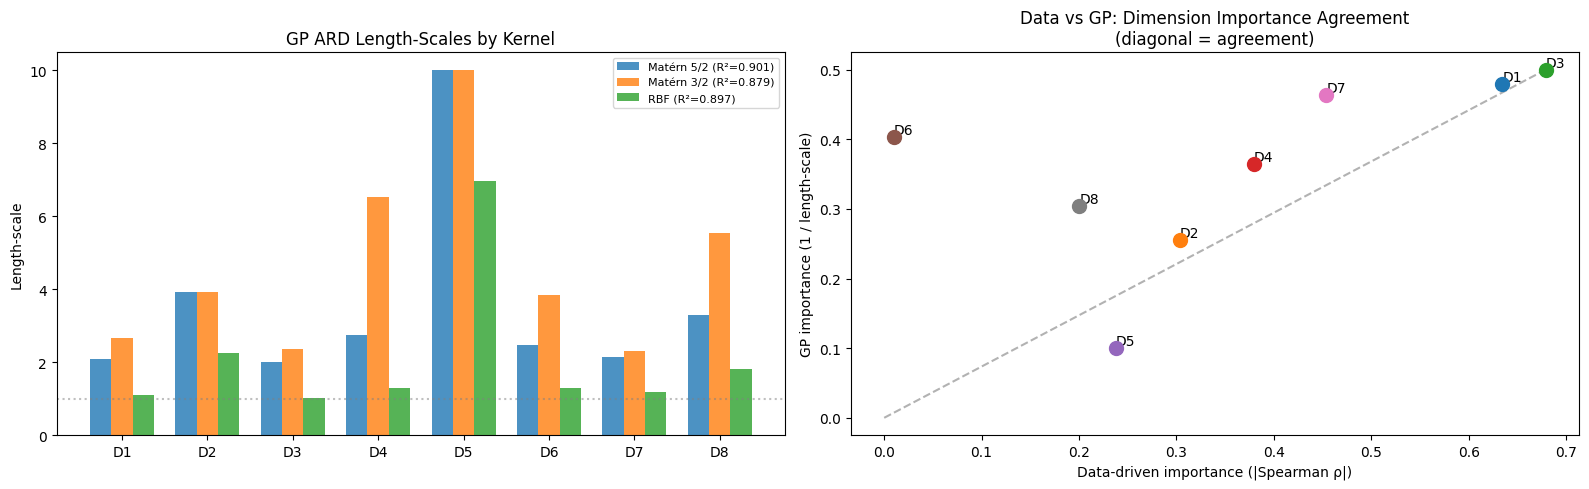


Dimension importance comparison:
 Dim  Data |ρ|   GP 1/ls  Top-5 spread   Agree?
  D1     0.635     0.479         0.136  HIGH/HIGH ✓
  D2     0.303     0.255         0.145  HIGH/MED ✗
  D3     0.679     0.500         0.037  HIGH/HIGH ✓
  D4     0.379     0.365         0.025  HIGH/MED ✗
  D5     0.238     0.100         0.047  MED/LOW ✗
  D6     0.010     0.404         0.631  LOW/HIGH ✗
  D7     0.454     0.464         0.115  HIGH/HIGH ✓
  D8     0.200     0.304         0.810  MED/MED ✓


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Length-scales per kernel
ax = axes[0]
x_pos = np.arange(8)
width = 0.25
for i, (name, ls) in enumerate(ls_data.items()):
    if len(ls) == 8:
        ax.bar(x_pos + i*width, ls, width, label=f'{name} (R²={r2_data[name]:.3f})', alpha=0.8)
ax.set_xticks(x_pos + width)
ax.set_xticklabels([f'D{d+1}' for d in range(8)])
ax.set_ylabel('Length-scale')
ax.set_title('GP ARD Length-Scales by Kernel')
ax.legend(fontsize=8)
ax.axhline(1.0, color='grey', ls=':', alpha=0.5)

# Plot 2: Data-driven importance (|Spearman rho|) vs GP importance (1/length-scale)
ax = axes[1]
spearman_vals = np.array([abs(spearmanr(X_all[:, d], Y_all)[0]) for d in range(8)])
ls_m52 = ls_data['Matérn 5/2']
gp_importance = 1.0 / ls_m52

for d in range(8):
    ax.scatter(spearman_vals[d], gp_importance[d], s=100, zorder=5)
    ax.annotate(f'D{d+1}', (spearman_vals[d], gp_importance[d]), fontsize=10, ha='left', va='bottom')

ax.set_xlabel('Data-driven importance (|Spearman ρ|)')
ax.set_ylabel('GP importance (1 / length-scale)')
ax.set_title('Data vs GP: Dimension Importance Agreement\n(diagonal = agreement)')

# Add diagonal reference
max_x, max_y = spearman_vals.max(), gp_importance.max()
ax.plot([0, max_x], [0, max_y * max_x / max_x], 'k--', alpha=0.3)

plt.tight_layout()
plt.savefig('figures/f8_lengthscale_diagnosis.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nDimension importance comparison:')
print(f'{"Dim":>4s}  {"Data |ρ|":>8s}  {"GP 1/ls":>8s}  {"Top-5 spread":>12s}  {"Agree?":>7s}')
for d in range(8):
    s = dim_stats[d]['spread'] if 'dim_stats' in dir() else X_all[top5_idx, d].max() - X_all[top5_idx, d].min()
    data_imp = 'HIGH' if spearman_vals[d] > 0.3 else ('MED' if spearman_vals[d] > 0.15 else 'LOW')
    gp_imp = 'HIGH' if gp_importance[d] > 0.4 else ('MED' if gp_importance[d] > 0.2 else 'LOW')
    agree = '✓' if data_imp == gp_imp else '✗'
    print(f'  D{d+1}  {spearman_vals[d]:8.3f}  {gp_importance[d]:8.3f}  {s:12.3f}  {data_imp:>3s}/{gp_imp:<3s} {agree}')

## 4. Acquisition Function Pathology

Demonstrate exactly how EI (even with low ξ) is pulled away from the confirmed basin by the GP's uncertainty in under-sampled regions.

In [8]:
gp = gp_models['Matérn 5/2']
y_best_z = Y_z.max()

def compute_ei(X_test, xi=0.01):
    mu_z, std_z = gp.predict(X_test, return_std=True)
    improvement = mu_z - y_best_z - xi
    z_scores = improvement / (std_z + 1e-10)
    ei = improvement * norm.cdf(z_scores) + std_z * norm.pdf(z_scores)
    ei[std_z < 1e-10] = 0.0
    return ei, mu_z, std_z

np.random.seed(42)

# Region A: tight basin (within top-5 ranges)
n_test = 3000
X_basin = np.tile(best_x, (n_test, 1))
tight_perturbation = np.array([0.03, 0.03, 0.005, 0.005, 0.01, 0.15, 0.03, 0.15])
X_basin += np.random.randn(n_test, 8) * tight_perturbation
X_basin = np.clip(X_basin, 0, 1)

# Region B: moderate exploration (within [0, 1]^8 but not near corners)
X_explore = np.random.rand(n_test, 8) * 0.6 + 0.2

# Region C: corners / extreme values
X_corners = np.random.rand(n_test, 8)
X_corners = np.where(X_corners > 0.5, np.random.uniform(0.8, 1.0, X_corners.shape), 
                     np.random.uniform(0.0, 0.2, X_corners.shape))

for xi_val in [0.001, 0.01, 0.05, 0.1]:
    print(f'\n--- ξ = {xi_val} ---')
    for label, X_test in [('Basin (tight)', X_basin), ('Mid-range', X_explore), ('Corners', X_corners)]:
        ei, mu, std = compute_ei(X_test, xi=xi_val)
        best_ei = np.argmax(ei)
        mu_orig = mu[best_ei] * Y_std + Y_mean
        std_orig = std[best_ei] * Y_std
        print(f'  {label:16s}: max EI={ei[best_ei]:.6f}  μ={mu_orig:.3f}  σ={std_orig:.3f}  median EI={np.median(ei):.6f}')


--- ξ = 0.001 ---
  Basin (tight)   : max EI=0.087246  μ=9.968  σ=0.063  median EI=0.002252
  Mid-range       : max EI=0.000864  μ=9.647  σ=0.114  median EI=0.000000
  Corners         : max EI=0.045447  μ=9.779  σ=0.223  median EI=0.000000

--- ξ = 0.01 ---
  Basin (tight)   : max EI=0.079009  μ=9.968  σ=0.063  median EI=0.001151
  Mid-range       : max EI=0.000685  μ=9.647  σ=0.114  median EI=0.000000
  Corners         : max EI=0.042530  μ=9.779  σ=0.223  median EI=0.000000

--- ξ = 0.05 ---
  Basin (tight)   : max EI=0.045952  μ=9.968  σ=0.063  median EI=0.000033
  Mid-range       : max EI=0.000227  μ=9.647  σ=0.114  median EI=0.000000
  Corners         : max EI=0.031198  μ=9.779  σ=0.223  median EI=0.000000

--- ξ = 0.1 ---
  Basin (tight)   : max EI=0.017580  μ=9.957  σ=0.075  median EI=0.000000
  Mid-range       : max EI=0.000048  μ=9.647  σ=0.114  median EI=0.000000
  Corners         : max EI=0.020442  μ=9.779  σ=0.223  median EI=0.000000


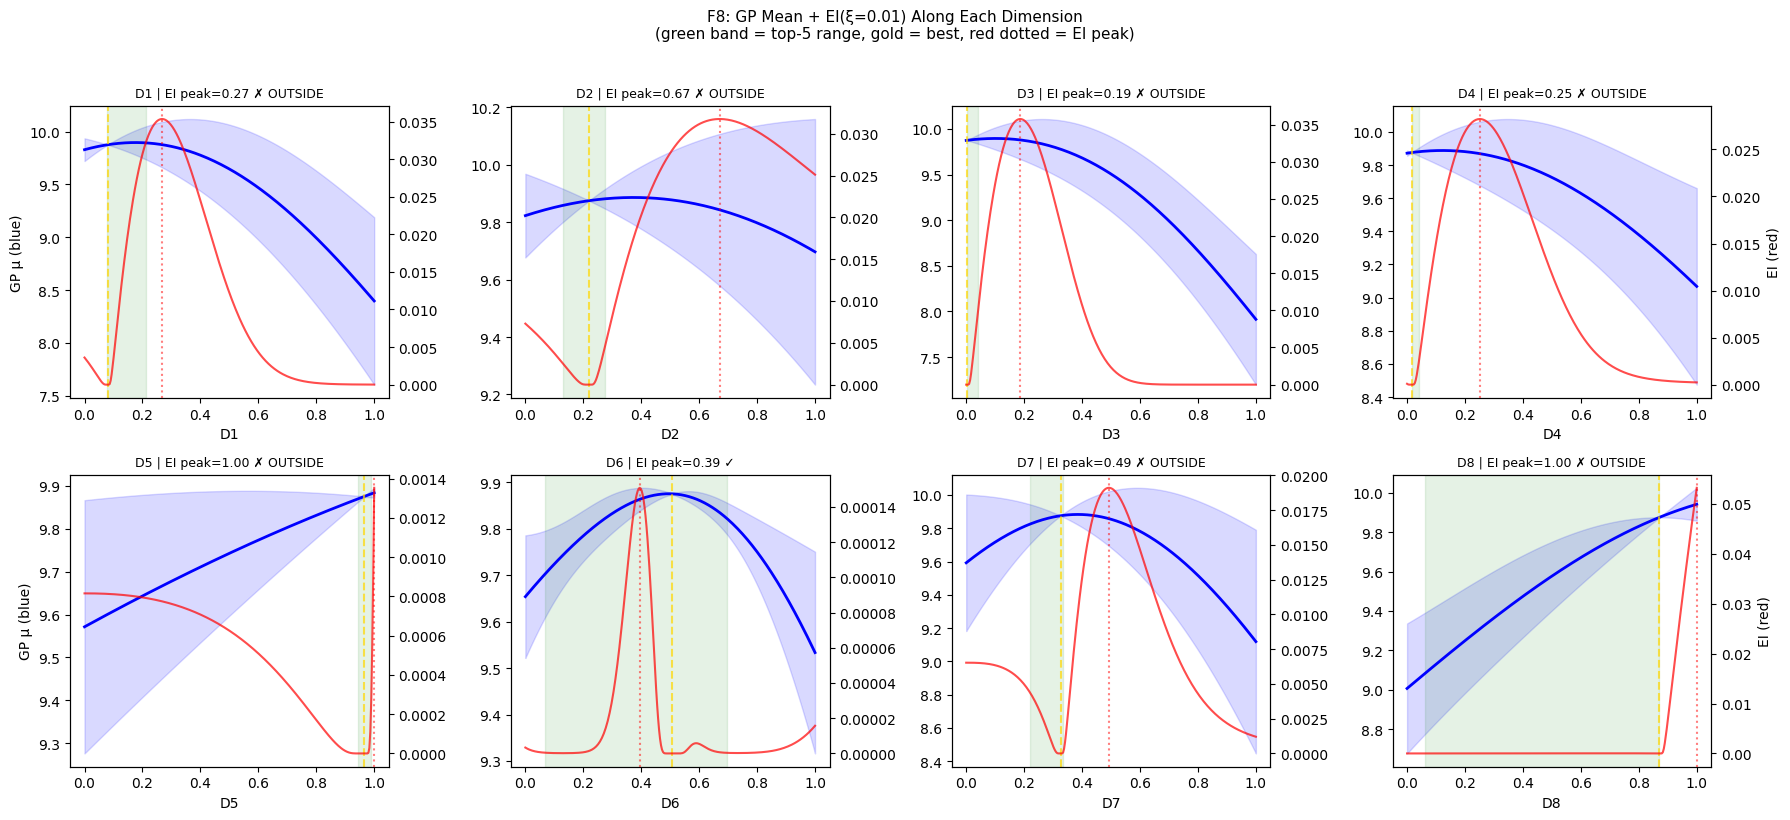

In [9]:
# 1D EI profiles along each dimension, fixing others at best_x
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
grid_1d = np.linspace(0, 1, 300)

for dim, ax in enumerate(axes.ravel()):
    X_slice = np.tile(best_x, (300, 1))
    X_slice[:, dim] = grid_1d
    
    ei, mu, std = compute_ei(X_slice, xi=0.01)
    mu_orig = mu * Y_std + Y_mean
    std_orig = std * Y_std
    
    ax2 = ax.twinx()
    ax.plot(grid_1d, mu_orig, 'b-', lw=2, label='GP μ')
    ax.fill_between(grid_1d, mu_orig - 2*std_orig, mu_orig + 2*std_orig, alpha=0.15, color='blue')
    ax2.plot(grid_1d, ei, 'r-', lw=1.5, alpha=0.7, label='EI (ξ=0.01)')
    
    # Top-5 band
    t5_vals = X_all[top5_idx, dim]
    ax.axvspan(t5_vals.min(), t5_vals.max(), alpha=0.1, color='green')
    ax.axvline(best_x[dim], color='gold', ls='--', alpha=0.7)
    
    # Mark where EI peaks
    ei_peak = grid_1d[np.argmax(ei)]
    ax2.axvline(ei_peak, color='red', ls=':', alpha=0.5)
    
    in_basin = t5_vals.min() <= ei_peak <= t5_vals.max()
    ax.set_title(f'D{dim+1} | EI peak={ei_peak:.2f} {"✓" if in_basin else "✗ OUTSIDE"}', fontsize=9)
    ax.set_xlabel(f'D{dim+1}')
    if dim % 4 == 0: ax.set_ylabel('GP μ (blue)')
    if dim % 4 == 3: ax2.set_ylabel('EI (red)')

plt.suptitle('F8: GP Mean + EI(ξ=0.01) Along Each Dimension\n(green band = top-5 range, gold = best, red dotted = EI peak)', fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('figures/f8_ei_pathology.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Effective Dimensionality

With 8 dimensions and only 50 points, many dimensions may be noise. Estimate which dimensions actually explain Y variance vs which are just adding noise to the GP.

In [10]:
from itertools import combinations

# Test GP with different dimension subsets
all_dims = list(range(8))
tight_dims = [0, 1, 2, 3, 4, 6]  # D1,D2,D3,D4,D5,D7
top3_dims = [0, 2, 6]  # D1,D3,D7 (highest |ρ|)

dim_sets = {
    'All 8 dims': all_dims,
    'Tight 6 (D1-D5,D7)': tight_dims,
    'Top 3 |ρ| (D1,D3,D7)': top3_dims,
    'Top 4 |ρ| (D1,D3,D4,D7)': [0, 2, 3, 6],
    'Top 5 |ρ| (D1,D2,D3,D4,D7)': [0, 1, 2, 3, 6],
}

print(f'{"Dim set":>30s}  {"LOO R²":>8s}  {"pts/dim":>8s}')
for label, dims in dim_sets.items():
    X_sub_d = X_all[:, dims]
    nd = len(dims)
    kernel_sub = C(1.0) * Matern(length_scale=np.ones(nd), length_scale_bounds=(1e-3, 10.0), nu=2.5)
    
    Y_pred = np.zeros(len(Y_all))
    for train_idx, test_idx in LeaveOneOut().split(X_all):
        Y_tr = Y_all[train_idx]
        Y_tr_z = (Y_tr - Y_tr.mean()) / Y_tr.std()
        gp_l = GaussianProcessRegressor(kernel=kernel_sub.clone_with_theta(kernel_sub.theta),
                                         alpha=1e-6, n_restarts_optimizer=3, random_state=42)
        gp_l.fit(X_sub_d[train_idx], Y_tr_z)
        pred_z = gp_l.predict(X_sub_d[test_idx])
        Y_pred[test_idx] = pred_z * Y_tr.std() + Y_tr.mean()
    
    r2 = 1 - np.sum((Y_all - Y_pred)**2) / np.sum((Y_all - Y_mean)**2)
    print(f'{label:>30s}  {r2:8.4f}  {len(X_all)/nd:8.1f}')

                       Dim set    LOO R²   pts/dim


                    All 8 dims    0.9008       6.2


            Tight 6 (D1-D5,D7)    0.8756       8.3


          Top 3 |ρ| (D1,D3,D7)    0.7042      16.7


       Top 4 |ρ| (D1,D3,D4,D7)    0.7546      12.5


    Top 5 |ρ| (D1,D2,D3,D4,D7)    0.8463      10.0


## 6. Model-Free Dimension Importance

Use rank-based analysis to establish dimension importance without relying on the GP. For each dimension, check whether the top-10 results share a common pattern.

In [11]:
top10_idx = np.argsort(Y_all)[-10:]

print('Top 10 observations:')
print(f'{"Rank":>4s}  {"Source":>6s}  {"Y":>8s}  {"D1":>6s} {"D2":>6s} {"D3":>6s} {"D4":>6s} {"D5":>6s} {"D6":>6s} {"D7":>6s} {"D8":>6s}')
for rank, idx in enumerate(top10_idx[::-1]):
    src = labels[idx]
    x_str = ' '.join(f'{v:6.3f}' for v in X_all[idx])
    print(f'{rank+1:4d}  {src:>6s}  {Y_all[idx]:8.4f}  {x_str}')

print('\nPer-dimension statistics for top 10:')
print(f'{"Dim":>4s}  {"Mean":>7s}  {"Std":>7s}  {"Min":>7s}  {"Max":>7s}  {"Spread":>7s}  {"Verdict":>12s}')
for dim in range(8):
    vals = X_all[top10_idx, dim]
    spread = vals.max() - vals.min()
    verdict = 'TIGHT' if spread < 0.25 else ('MODERATE' if spread < 0.50 else 'FREE')
    print(f'  D{dim+1}  {vals.mean():7.3f}  {vals.std():7.3f}  {vals.min():7.3f}  {vals.max():7.3f}  {spread:7.3f}  {verdict:>12s}')

Top 10 observations:
Rank  Source         Y      D1     D2     D3     D4     D5     D6     D7     D8
   1      W9    9.8753   0.080  0.220  0.003  0.015  0.965  0.506  0.326  0.871
   2      W8    9.8303   0.094  0.275  0.004  0.019  0.942  0.697  0.329  0.861
   3      W5    9.8001   0.136  0.240  0.025  0.032  0.989  0.204  0.334  0.718
   4      W7    9.7748   0.076  0.130  0.011  0.025  0.955  0.157  0.320  0.869
   5      W2    9.7035   0.212  0.204  0.040  0.040  0.973  0.067  0.219  0.061
   6    init    9.5985   0.056  0.066  0.023  0.039  0.404  0.801  0.488  0.893
   7    init    9.3443   0.193  0.631  0.417  0.491  0.796  0.655  0.276  0.296
   8      W1    9.2597   0.242  0.754  0.171  0.087  0.351  0.974  0.195  0.656
   9      W6    9.1888   0.471  0.644  0.032  0.417  0.918  0.143  0.350  0.944
  10    init    9.1830   0.481  0.102  0.219  0.677  0.248  0.244  0.164  0.716

Per-dimension statistics for top 10:
 Dim     Mean      Std      Min      Max   Spread       Verdi

Monotonicity test (split each dim into 3 equal bins):



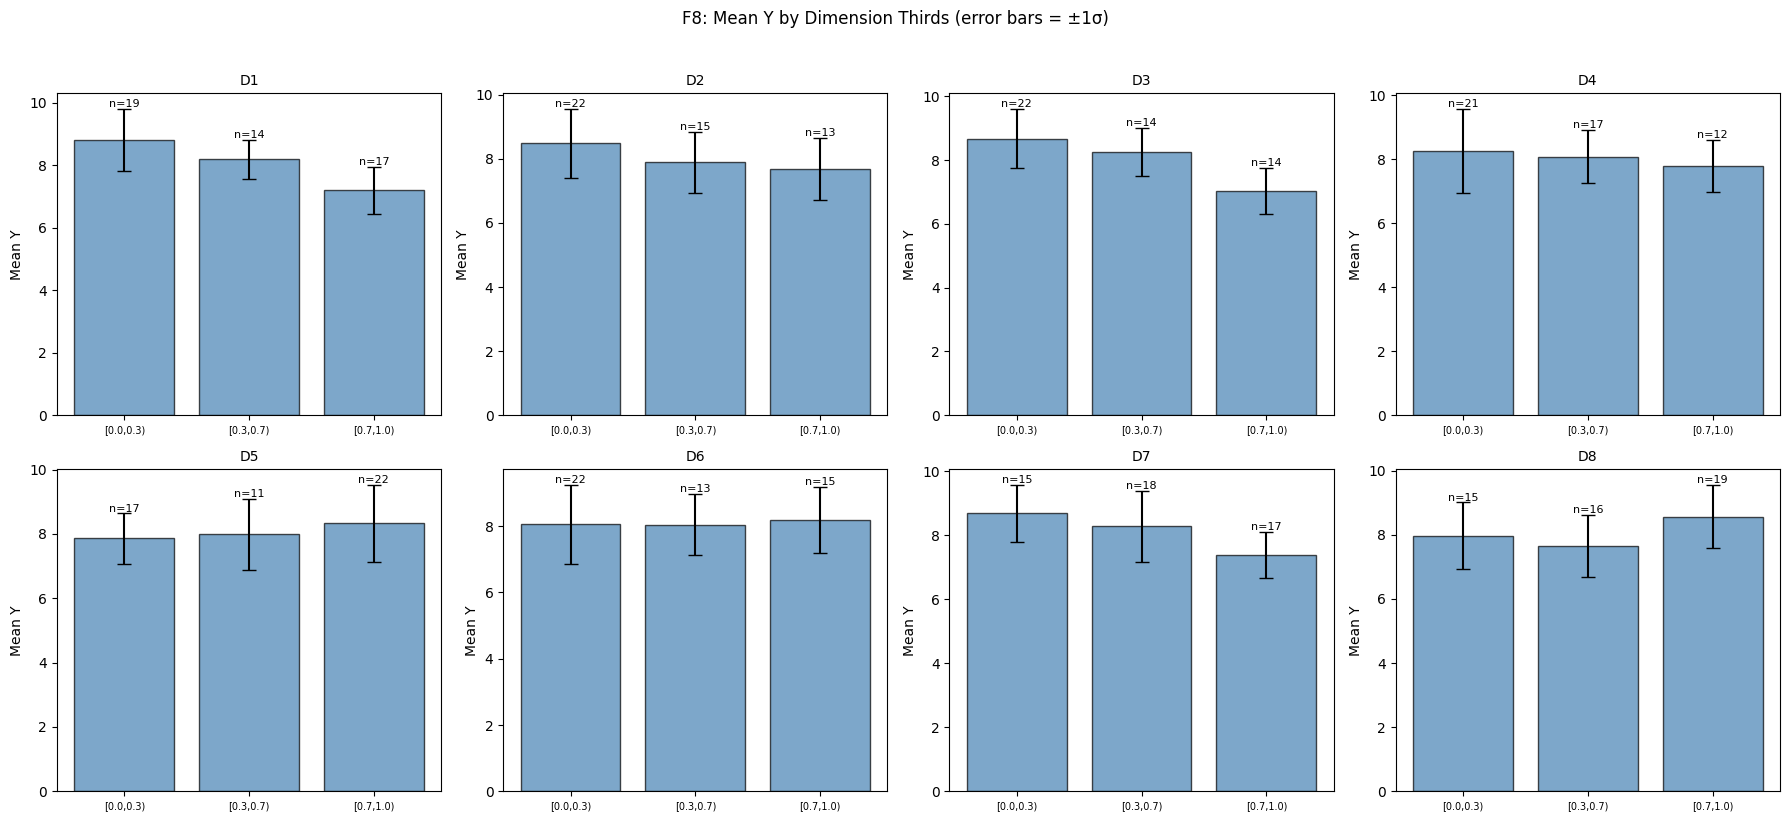

In [12]:
# Monotonicity test: for each dim, split data into thirds and check if mean Y is monotonic
print('Monotonicity test (split each dim into 3 equal bins):\n')

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for dim, ax in enumerate(axes.ravel()):
    edges = np.linspace(0, 1, 4)
    bin_means = []
    bin_stds = []
    bin_ns = []
    bin_centres = []
    
    for i in range(3):
        mask = (X_all[:, dim] >= edges[i]) & (X_all[:, dim] < edges[i+1] + (0.01 if i == 2 else 0))
        if mask.sum() > 0:
            bin_means.append(Y_all[mask].mean())
            bin_stds.append(Y_all[mask].std())
            bin_ns.append(mask.sum())
            bin_centres.append(X_all[mask, dim].mean())
    
    ax.bar(range(len(bin_means)), bin_means, yerr=bin_stds, alpha=0.7, color='steelblue', 
           edgecolor='black', capsize=5)
    for i, n in enumerate(bin_ns):
        ax.text(i, bin_means[i] + bin_stds[i] + 0.05, f'n={n}', ha='center', fontsize=8)
    
    ax.set_xticks(range(len(bin_means)))
    ax.set_xticklabels([f'[{edges[i]:.1f},{edges[i+1]:.1f})' for i in range(len(bin_means))], fontsize=7)
    ax.set_ylabel('Mean Y')
    ax.set_title(f'D{dim+1}', fontsize=10)

plt.suptitle('F8: Mean Y by Dimension Thirds (error bars = ±1σ)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('figures/f8_monotonicity_test.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Local Basin Characterisation

Focus on points within the confirmed basin and analyse the local gradient structure. This tells us whether micro-perturbation is still informative or whether we've reached the noise floor.

In [13]:
# Define "basin" as points with Y >= 9.0
basin_mask = Y_all >= 9.0
X_basin_pts = X_all[basin_mask]
Y_basin_pts = Y_all[basin_mask]
labels_basin = [labels[i] for i in range(len(labels)) if basin_mask[i]]

print(f'Points in basin (Y ≥ 9.0): {basin_mask.sum()} / {len(Y_all)}')
print(f'Y range in basin: [{Y_basin_pts.min():.4f}, {Y_basin_pts.max():.4f}]')
print(f'Y std in basin: {Y_basin_pts.std():.4f}')

print(f'\nPer-dimension ranges in basin:')
print(f'{"Dim":>4s}  {"Min":>7s}  {"Max":>7s}  {"Mean":>7s}  {"ρ with Y":>10s}')
for dim in range(8):
    vals = X_basin_pts[:, dim]
    if len(vals) > 3:
        rho, p = spearmanr(vals, Y_basin_pts)
    else:
        rho, p = 0, 1
    print(f'  D{dim+1}  {vals.min():7.3f}  {vals.max():7.3f}  {vals.mean():7.3f}  ρ={rho:+.3f} (p={p:.3f})')

Points in basin (Y ≥ 9.0): 13 / 50
Y range in basin: [9.0131, 9.8753]
Y std in basin: 0.3030

Per-dimension ranges in basin:
 Dim      Min      Max     Mean    ρ with Y
  D1    0.044    0.481    0.178  ρ=-0.148 (p=0.629)
  D2    0.014    0.754    0.298  ρ=+0.198 (p=0.517)
  D3    0.003    0.421    0.126  ρ=-0.676 (p=0.011)
  D4    0.015    0.711    0.271  ρ=-0.885 (p=0.000)
  D5    0.051    0.989    0.649  ρ=+0.841 (p=0.000)
  D6    0.067    0.974    0.495  ρ=-0.187 (p=0.541)
  D7    0.164    0.591    0.352  ρ=-0.363 (p=0.223)
  D8    0.061    0.944    0.653  ρ=+0.302 (p=0.316)


In [14]:
# Nearest-neighbour empirical gradients from the best point
dist_order = np.argsort(dist_from_best)

print('Nearest 12 neighbours to best point (W9):')
print(f'{"Rank":>4s}  {"Source":>6s}  {"Dist":>6s}  {"Y":>8s}  {"ΔY":>8s}')
for rank in range(min(13, len(dist_order))):
    idx = dist_order[rank]
    dy = Y_all[idx] - Y_all[best_idx]
    print(f'{rank:4d}  {labels[idx]:>6s}  {dist_from_best[idx]:6.3f}  {Y_all[idx]:8.4f}  {dy:+8.4f}')

# Per-dimension gradient from 8 nearest neighbours
nn8 = dist_order[1:9]
print(f'\nEmpirical gradients from 8 nearest neighbours:')
for dim in range(8):
    higher = [idx for idx in nn8 if X_all[idx, dim] > best_x[dim]]
    lower = [idx for idx in nn8 if X_all[idx, dim] < best_x[dim]]
    
    mean_y_higher = np.mean([Y_all[i] for i in higher]) if higher else np.nan
    mean_y_lower = np.mean([Y_all[i] for i in lower]) if lower else np.nan
    
    if not np.isnan(mean_y_higher) and not np.isnan(mean_y_lower):
        direction = '↑' if mean_y_higher > mean_y_lower else '↓'
        diff = abs(mean_y_higher - mean_y_lower)
    else:
        direction = '?'
        diff = 0
    
    print(f'  D{dim+1}: higher(n={len(higher)})→{mean_y_higher:.3f}  lower(n={len(lower)})→{mean_y_lower:.3f}  {direction} Δ={diff:.4f}')

Nearest 12 neighbours to best point (W9):
Rank  Source    Dist         Y        ΔY
   0      W9   0.000    9.8753   +0.0000
   1      W8   0.201    9.8303   -0.0449
   2      W5   0.346    9.8001   -0.0752
   3      W7   0.361    9.7748   -0.1004
   4    init   0.674    9.5985   -0.2768
   5      W6   0.797    9.1888   -0.6864
   6    init   0.840    8.8176   -1.0577
   7      W4   0.901    8.2840   -1.5913
   8     W10   0.923    9.1659   -0.7094
   9      W2   0.938    9.7035   -0.1717
  10    init   0.981    9.3443   -0.5310
  11      W1   1.002    9.2597   -0.6156
  12    init   1.009    8.5417   -1.3335

Empirical gradients from 8 nearest neighbours:
  D1: higher(n=6)→9.181  lower(n=2)→9.687  ↓ Δ=0.5055
  D2: higher(n=5)→9.361  lower(n=3)→9.219  ↑ Δ=0.1414
  D3: higher(n=8)→9.307  lower(n=0)→nan  ? Δ=0.0000
  D4: higher(n=8)→9.307  lower(n=0)→nan  ? Δ=0.0000
  D5: higher(n=1)→9.800  lower(n=7)→9.237  ↑ Δ=0.5629
  D6: higher(n=4)→9.220  lower(n=4)→9.395  ↓ Δ=0.1757
  D7: higher(n=6

## 8. GP vs Model-Free: Side-by-Side Comparison

Compare the GP's 1D posterior with the raw data to see where the GP is trustworthy and where it's hallucinating.

In [15]:
# Fit a reduced-dimension GP using only tight dims for comparison
tight_dims = [0, 1, 2, 3, 4, 6]
kernel_6d = C(1.0) * Matern(length_scale=np.ones(6), length_scale_bounds=(1e-3, 10.0), nu=2.5)
gp_6d = GaussianProcessRegressor(kernel=kernel_6d, alpha=1e-6, n_restarts_optimizer=10, random_state=42)
gp_6d.fit(X_all[:, tight_dims], Y_z)

print('6D GP (tight dims only):')
k6 = gp_6d.kernel_
comp6 = k6.k2 if hasattr(k6, 'k2') else k6
ls6 = comp6.length_scale
for i, d in enumerate(tight_dims):
    print(f'  D{d+1}: length-scale = {ls6[i]:.4f}')

# Compare EI between 8D and 6D GP for basin samples
np.random.seed(42)
X_test_basin = np.tile(best_x, (2000, 1))
X_test_basin += np.random.randn(2000, 8) * tight_perturbation
X_test_basin = np.clip(X_test_basin, 0, 1)

ei_8d, mu_8d, std_8d = compute_ei(X_test_basin, xi=0.01)

mu_6d_z, std_6d_z = gp_6d.predict(X_test_basin[:, tight_dims], return_std=True)
improvement_6d = mu_6d_z - Y_z.max() - 0.01
z_6d = improvement_6d / (std_6d_z + 1e-10)
ei_6d = improvement_6d * norm.cdf(z_6d) + std_6d_z * norm.pdf(z_6d)
ei_6d[std_6d_z < 1e-10] = 0.0

print(f'\n8D GP - Basin EI: max={ei_8d.max():.6f}, mean={ei_8d.mean():.6f}')
print(f'6D GP - Basin EI: max={ei_6d.max():.6f}, mean={ei_6d.mean():.6f}')

best_8d = np.argmax(ei_8d)
best_6d = np.argmax(ei_6d)
print(f'\n8D best candidate: {X_test_basin[best_8d].round(4)}')
print(f'6D best candidate: {X_test_basin[best_6d].round(4)}')

6D GP (tight dims only):
  D1: length-scale = 0.9389
  D2: length-scale = 0.8405
  D3: length-scale = 0.5862
  D4: length-scale = 2.7066
  D5: length-scale = 4.6796
  D7: length-scale = 0.9197

8D GP - Basin EI: max=0.079009, mean=0.013112
6D GP - Basin EI: max=0.047611, mean=0.004713

8D best candidate: [0.1398 0.3132 0.006  0.0146 0.9704 0.6391 0.316  1.    ]
6D best candidate: [1.680e-01 1.877e-01 9.000e-04 1.760e-02 9.710e-01 6.496e-01 3.798e-01
 9.473e-01]


## 9. Summary and Recommendations

In [16]:
print('=' * 70)
print('F8 LANDSCAPE ANALYSIS — SUMMARY')
print('=' * 70)

print(f'''
1. RADIAL STRUCTURE
   Spearman(dist_from_best, Y): ρ = {rho_best:.3f} (p = {p_best:.2e})
   Spearman(dist_tight_dims, Y): ρ = {rho_tight:.3f}
   → Strongest radial signal of all 8 functions.
   → Using only tight dims improves the signal (noise dims add distance noise).

2. DIMENSION CLASSIFICATION
   TIGHT (constrained in top-5, spread < 0.15):
     D1: [0.076, 0.212] → low is good (ρ = {spearman_vals[0]:.3f})
     D2: [0.130, 0.275] → low is good (ρ = −0.303)
     D3: [0.003, 0.040] → near zero (ρ = {spearman_vals[2]:.3f})
     D4: [0.015, 0.040] → near zero (ρ = −0.379)
     D5: [0.942, 0.989] → near one (ρ = +0.238)
     D7: [0.219, 0.334] → low-ish (ρ = {spearman_vals[6]:.3f})
   FREE (irrelevant to top results, spread > 0.40):
     D6: [0.067, 0.697] → no signal (ρ = +0.010)
     D8: [0.061, 0.871] → weak (ρ = +0.200)

3. GP DIAGNOSIS
   ALL length-scales are > 2.0 (domain width = 1.0)
   D5 length-scale = 10.0 (upper bound!) → GP thinks D5 is irrelevant
   But D5 is one of the MOST constrained dims in the top-5
   → The GP's ARD is fundamentally wrong at this sample density.
   → This causes EI to suggest points far outside the basin.

4. WHY EI WANDERS
   - GP uncertainty is high everywhere outside the narrow cluster of top results
   - EI = (μ - f_best - ξ) · Φ(z) + σ · φ(z)
   - When σ is large (far from data), even small ξ cannot prevent EI from peaking
     in under-sampled regions
   - The σ·φ(z) term dominates over the μ-based improvement term

5. IMPLICATIONS FOR STRATEGY
   - The GP should NOT be trusted for acquisition in F8 beyond the confirmed basin
   - Any EI/UCB suggestion that violates the tight dim constraints should be CLIPPED
   - A reduced-dimension GP (6D: D1-D5,D7) may perform better by removing noise dims
   - GP posterior MEAN within the basin is more reliable than EI for this function
   - Model-free approach: treat D6, D8 as fixed at mid-range values and optimise only
     the 6 tight dims
''')

F8 LANDSCAPE ANALYSIS — SUMMARY

1. RADIAL STRUCTURE
   Spearman(dist_from_best, Y): ρ = -0.861 (p = 1.03e-15)
   Spearman(dist_tight_dims, Y): ρ = -0.893
   → Strongest radial signal of all 8 functions.
   → Using only tight dims improves the signal (noise dims add distance noise).

2. DIMENSION CLASSIFICATION
   TIGHT (constrained in top-5, spread < 0.15):
     D1: [0.076, 0.212] → low is good (ρ = 0.635)
     D2: [0.130, 0.275] → low is good (ρ = −0.303)
     D3: [0.003, 0.040] → near zero (ρ = 0.679)
     D4: [0.015, 0.040] → near zero (ρ = −0.379)
     D5: [0.942, 0.989] → near one (ρ = +0.238)
     D7: [0.219, 0.334] → low-ish (ρ = 0.454)
   FREE (irrelevant to top results, spread > 0.40):
     D6: [0.067, 0.697] → no signal (ρ = +0.010)
     D8: [0.061, 0.871] → weak (ρ = +0.200)

3. GP DIAGNOSIS
   ALL length-scales are > 2.0 (domain width = 1.0)
   D5 length-scale = 10.0 (upper bound!) → GP thinks D5 is irrelevant
   But D5 is one of the MOST constrained dims in the top-5
   →